## Exact cik list for DirectEdgar

* We will extract the list of CIKs from Compustat and export list to .CSV file.
  * The .CSV file serves as the input to the query on DirectEdgar's platform. 
  * This ensures the tax rate reconciliation results that we return only relate to the CIKs that appear in the .CSV file. 
* More information about the Query Tool is available on the DirectEdgar blog at the following link: https://directedgar.blog/support/query-tool/.

In [1]:
from pathlib import Path
import pandas as pd
import re

base_path = Path("/Users/anhnguyen/Library/CloudStorage/Box-Box/My Box Notes/Fall 2025/AAE 722 Machine Learning in Applied Economic Analysis/Final Project/Scripts")


input_path = base_path / "../Data/Data Compustat 2011-2025July ETR.dta"
ciks_path = base_path / "../Data/ciks.csv"

# 1. Load Compustat dataset
df = pd.read_stata(input_path)

# 2. Keep fiscal years 2018–2024
df = df[(df["fyear"] >= 2018) & (df["fyear"] <= 2024)]

# 3. Drop observations with missing or zero assets / stock price
df = df[df["at"].notna() & (df["at"] != 0)]
df = df[df["prcc_f"].notna() & (df["prcc_f"] != 0)]

# 4. Keep only CIK column
df = df[["cik"]].copy()

# 5. Drop missing / empty CIKs
df = df[df["cik"].notna() & (df["cik"] != "")]

# 6. Drop duplicate CIKs
df = df.drop_duplicates(subset="cik")

# 7. Rename cik -> CIK
df = df.rename(columns={"cik": "CIK"})

# 8. "Destring" CIK (convert to integer)
df["CIK"] = pd.to_numeric(df["CIK"], errors="raise", downcast="integer")

# 9. Export list to CSV
df.to_csv(ciks_path, index=False)

print(df.shape)

(8881, 1)


## Clean DirectEdgar Dataset

* We are comfortable that DirectEdgar is a reliable source.:
  * Of the 8,881 CIKs that we used in our DirectEdgar query, 3,171 did not return any data. 
  * Based on random inspection of 15 unmatched CIKs and coummincating with DirectEdgar, the primary reasons CIKs are not returned in a search are 
    * (i) they belonged to foreign filers (the majority), 
    * (ii) they belonged to investment vehicles, not actual firms, 
    * (iii) the XBRL tags did not align with the HTML labels in the filing which prevented DirectEdgar from assigning values to labels, 
    * (iv) the CIK was a publicly traded subsidiary which prevents DiectEdgar from cleanly assigning data, or 
    * (v) the CIK was backfiled by Compustat (following a merger, etc.) and does not match CIKs attached to filings on the SEC website. 
  * In total, only 1 of the CIKs randomly sampled, fell outside of category (i) and (ii).

* ETR columns definitions: https://directedgar.blog/support/effective-tax-rate-reconciliation/?keywords=effective+tax.

In [2]:
base_path = Path("/Users/anhnguyen/Library/CloudStorage/Box-Box/My Box Notes/Fall 2025/AAE 722 Machine Learning in Applied Economic Analysis/Final Project/Scripts")

taxrecs_path = base_path / "../Data/tax_recs_2018_2025.csv"

# 1. Load DirectEdgar data
df_de = pd.read_csv(taxrecs_path, dtype=str)

# 2. Make sure key numeric columns are numeric where needed
df_de["CIK"] = pd.to_numeric(df_de["CIK"], errors="coerce")
df_de["ROW_N"] = pd.to_numeric(df_de["ROW_N"], errors="coerce")

# 3. Drop bad data: drop if flag != ""
if "FLAG" in df_de.columns:
    df_de = df_de[df_de["FLAG"].isna() | (df_de["FLAG"] == "")]

# 4. Reformat fiscal year end: date_v = date(currentyear_end_date, "YMD")
df_de["date_v"] = pd.to_datetime(df_de["CURRENTYEAR_END_DATE"], errors="coerce")

# 5. Align datadate with month ends (following Stata logic)
df_de["month_dd"] = df_de["date_v"].dt.month
df_de["day_dd"] = df_de["date_v"].dt.day
df_de["year_dd"] = df_de["date_v"].dt.year

# 5.1 month_r
df_de["month_r"] = df_de["month_dd"]
mask_prev_month = (df_de["day_dd"] < 15) & (df_de["month_dd"] > 1)
df_de.loc[mask_prev_month, "month_r"] = df_de.loc[mask_prev_month, "month_dd"] - 1
mask_jan_prev_year = (df_de["day_dd"] < 15) & (df_de["month_dd"] == 1)
df_de.loc[mask_jan_prev_year, "month_r"] = 12

# 5.2 day_r
df_de["day_r"] = pd.NA
df_de.loc[df_de["month_r"] == 1, "day_r"] = 31
df_de.loc[
        (df_de["month_r"] == 2) & ~df_de["year_dd"].isin([2020, 2024]),
        "day_r"
    ] = 28
df_de.loc[
        (df_de["month_r"] == 2) & df_de["year_dd"].isin([2020, 2024]),
        "day_r"
    ] = 29
df_de.loc[df_de["month_r"] == 3, "day_r"] = 31
df_de.loc[df_de["month_r"] == 4, "day_r"] = 30
df_de.loc[df_de["month_r"] == 5, "day_r"] = 31
df_de.loc[df_de["month_r"] == 6, "day_r"] = 30
df_de.loc[df_de["month_r"] == 7, "day_r"] = 31
df_de.loc[df_de["month_r"] == 8, "day_r"] = 31
df_de.loc[df_de["month_r"] == 9, "day_r"] = 30
df_de.loc[df_de["month_r"] == 10, "day_r"] = 31
df_de.loc[df_de["month_r"] == 11, "day_r"] = 30
df_de.loc[df_de["month_r"] == 12, "day_r"] = 31

# 5.3 year_r
df_de["year_r"] = df_de["year_dd"]
mask_year_minus_1 = (df_de["month_dd"] == 1) & (df_de["day_dd"] < 15)
df_de.loc[mask_year_minus_1, "year_r"] = df_de.loc[mask_year_minus_1, "year_dd"] - 1

# 5.4 mdy = string(month_r, "%02.0f") + string(day_r, "%02.0f") + string(year_r)
df_de["month_r_str"] = df_de["month_r"].astype("Int64").astype(str).str.zfill(2)
df_de["day_r_str"] = df_de["day_r"].astype("Int64").astype(str).str.zfill(2)
df_de["year_r_str"] = df_de["year_r"].astype("Int64").astype(str)
df_de["mdy"] = df_de["month_r_str"] + df_de["day_r_str"] + df_de["year_r_str"]

# 6. datadate = date(mdy, "MDY")
df_de["datadate"] = pd.to_datetime(df_de["mdy"], format="%m%d%Y", errors="coerce")

# 7. Drop intermediate date variables: drop date_v *_dd *_r mdy
df_de = df_de.drop(
    columns=[
        "date_v",
        "month_dd", "day_dd", "year_dd",
        "month_r", "day_r", "year_r",
        "month_r_str", "day_r_str", "year_r_str",
        "mdy"
    ]
)

# print datadate dtypes and shape
print(df_de.shape)


(286838, 17)


## Create Opacity using clustering 

* We will use K-means clustering 
  * K = 3
  * Features = 3
    * Feature 1: an indicator whether a firm uses dollars to present information (1 = more opaque)
    * Feature 2: aggregation level, calculating as the ratio of the number of line items over total lagged assets multipled by negative 1 (higher = more opaque)
    * Feature 3: the share of other reconciling items (higher = more opaque)
    

### Create dollar column
* to check if the table_type == dollars

In [3]:
# Create indicator variables for disclosure of tax reconciliations in dollars
df_de["TABLE_TYPE"] = df_de["TABLE_TYPE"].str.upper().str.strip()
df_de["dollars"] = (df_de["TABLE_TYPE"] == "DOLLARS").astype(int)

# Statistics on dollars variable
#print(df_de["dollars"].describe())

# Display value counts for dollars
print(df_de["dollars"].value_counts())


dollars
1    144939
0    141899
Name: count, dtype: int64


### Check scale for value of the data point for the current fiscal yea

In [4]:
# Check scale column
#if 'scale' in df_de.columns:
#    print(df_de['scale'].value_counts())


# check 1 observation with scale == -2
#print(df_de[(df_de['scale'] == '-2')][['CIK', 'datadate', 'orig_row_label', 'CURRENTYEAR','TABLE_TYPE','dollars','scale',]])

# check 1 observation with scale == -2 and dollars == 1
#print(df_de[(df_de['scale'] == '-2') & (df_de['dollars'] == 1)][['CIK', 'datadate','orig_row_label', 'CURRENTYEAR','TABLE_TYPE','dollars','scale',]])

# From what I check:
# scale = -2, -4, -3, 1, -1, 1, 2 means dollars = 0 (percent)
# scale = 3,6,0 means dollars = 1 (dollars)

# print cik = 1770561 and datdate = 2021-12-31
#print(df_de[(df_de['CIK'] == 1770561) & (df_de['datadate'] == '2021-12-31')][['CIK', 'datadate','scale' ,'orig_row_label', 'CURRENTYEAR','TABLE_TYPE','dollars','scale',]])

### Feature 1: Dollars_unit

In [5]:
# If scale in [3,6,0] → dollars = 1
scale_dollars_map = {
    '3': 1,
    '6': 1,
    '0': 1,
    '-2': 0,
    '-4': 0,
    '-3': 0,
    '1': 0,
    '-1': 0,
    '2': 0
}
df_de['scale'] = df_de['scale'].str.strip()
df_de['dollars'] = df_de.apply(
    lambda row: scale_dollars_map.get(row['scale'], row['dollars']),
    axis=1
)


# Convert row-level indicator → group-level indicator
df_de['dollars_unit'] = df_de.groupby(['CIK','datadate'])['dollars'].transform('max')

# check 1 observation with scale == -2 and dollars == 1
# print(df_de[(df_de['scale'] == '-2') & (df_de['dollars'] == 1)][['CIK', 'datadate','orig_row_label', 'CURRENTYEAR','TABLE_TYPE','dollars','scale',]])


### Dedupe

* Remove duplicates because firms use both units 

In [6]:
# Count rows per (CIK, datadate, table_type)
df_de["table_n"] = df_de.groupby(["CIK", "datadate", "TABLE_TYPE"])["CIK"].transform("size")

# Count rows per (CIK, datadate)
df_de["firm_n"] = df_de.groupby(["CIK", "datadate"])["CIK"].transform("size")

# multi_rec = 1 if firm has multiple reconciliations (i.e., uses both units)
df_de["multi_rec"] = (df_de["table_n"] != df_de["firm_n"]).astype(int)
df_de["disclose_both_units"] = df_de["multi_rec"]           # 1 = both dollar & percent, 0 = only one

# mask_firm_has_both = disclose_both_units == 1
mask_both = df_de["disclose_both_units"] == 1

# Drop the PERCENT row only when both units exist
df_de = df_de[~(mask_both & (df_de["TABLE_TYPE"] == "PERCENT"))]

# Drop intermediate counting variables
df_de = df_de.drop(columns=["table_n", "firm_n", "multi_rec"])

print(df_de.shape)

# Final statistics on dollars variable
# print(df_de["dollars"].value_counts())

(258192, 20)


* Drop duplicates line items

In [7]:
# Drop duplicates based on orig_row_label within (CIK, datadate)
df_de = df_de.sort_values(["CIK", "datadate", "orig_row_label"])

# N = _N (total rows in each group)
df_de["N"] = df_de.groupby(["CIK", "datadate", "orig_row_label"])["CIK"].transform("size")

# n = _n (row index inside group, starting at 1)
df_de["n"] = df_de.groupby(["CIK", "datadate", "orig_row_label"]).cumcount() + 1

# Drop if N > 1 & n != 1 (keep only the first occurrence)
df_de = df_de[~((df_de["N"] > 1) & (df_de["n"] != 1))].copy()

# Drop helper columns
df_de = df_de.drop(columns=["N", "n"])

print(df_de.shape)

(255812, 20)


* Duplicates due to incorrect row labelling by DirectEdgar 

In [8]:
# 1. Clean currentyear values 
df_de["CURRENTYEAR"] = df_de["CURRENTYEAR"].astype(str).str.strip() # CURRENTYEAR is the column that shows the value of the tax attribute

# drop missing CURRENTYEAR
df_de = df_de[df_de["CURRENTYEAR"].notna() & (df_de["CURRENTYEAR"] != "")]

# replace common formatting issues
df_de["CURRENTYEAR"] = df_de["CURRENTYEAR"].replace({
    "": ".",
    "-1,035,815": "-1035815",
    ".0": "0",
    "-833,505": "-833505",
    "1,524,637": "1524637",
    "3,519,246": "3519246",
    "44,605,000": "44605000"
})

df_de["CURRENTYEAR"] = df_de["CURRENTYEAR"].replace(".", pd.NA)

# destring currentyear, replace - We want to make sure this column is numeric 
df_de["CURRENTYEAR"] = pd.to_numeric(df_de["CURRENTYEAR"], errors="coerce")

# drop rows with missing CURRENTYEAR after destringing or value at 0
df_de = df_de[df_de["CURRENTYEAR"].notna() & (df_de["CURRENTYEAR"] != 0)]

# 2. Drop duplicates due to incorrect row labelling by DirectEdgar
df_de = df_de.sort_values(["CIK", "datadate", "ROW_N"])

df_de["N"] = df_de.groupby(["CIK", "datadate", "ROW_N"])["CIK"].transform("size")
df_de["max_n"] = df_de.groupby(["CIK", "datadate"])["N"].transform("max")

# 3. val_diff = currentyear - currentyear[_n-1] within (CIK, datadate, row_n)
df_de["val_diff"] = df_de.groupby(["CIK", "datadate", "ROW_N"])["CURRENTYEAR"].diff()

# 4. Drop if max_n > 1 & val_diff == 0  (true duplicates with same numeric value)
mask_drop = (df_de["max_n"] > 1) & (df_de["val_diff"] == 0)
df_de = df_de[~mask_drop].copy()

# 5. Drop helper variables
df_de = df_de.drop(columns=["N", "max_n", "val_diff"])

print(df_de.shape)



(236407, 20)


In [9]:
# Check within each (CIK, datadate), how many unique dollar values exist
df_de["unique_dollars"] = df_de.groupby(["CIK", "datadate"])["dollars"].transform("nunique")
# print value counts of unique_dollars
print(df_de["unique_dollars"].value_counts())

unique_dollars
1    215105
2     21302
Name: count, dtype: int64


### Create the number of etr line items

In [10]:
# Count etrrec_lines per (CIK, datadate)
df_de["etrrec_lines"] = df_de.groupby(["CIK","datadate"])["orig_row_label"].transform("size")

# Statistics on dollars variable
# print(df_de["etrrec_lines"].describe())


# Check the firm that have max etrrec_lines
# This is to investigate firms with large number of reconciliation lines
# Not issues found
#max_lines = df_de["etrrec_lines"].max()
#print(df_de[df_de["etrrec_lines"] == max_lines])

print(df_de.shape)



(236407, 22)


### Create other_flag column
* Flag row indentified as 'other'

In [11]:
# Lists for include/exclude patterns
pattern_include_list = [
    r'other', # generic keyword match
    r'other permanent', # specifically for strings containing other permanent
    r'other items', # targets buckets explicitly labeled other items
    r'other \d+', # other followed by a number
    r'other[_ ]', # other followed by underscore or space
    r'other rate differentials' # specifically for strings containing other rate differentials
]

pattern_exclude_list = [
    r'other\s+financial\s+terms', # "other financial terms" (with 1+ spaces between words)
    r'\b[\w\s]+,\s*other\s*$', # phrases ending with ", other"
    r'\b[\w\s]+(?:,)?\s+and\s+other\s*$', # phrases ending with "and other" or ", and other"
    r'\b[\w\s]+and\s+other\s*$' # phrases ending with "and other"

]

# Build regex patterns
pattern_include = "(" + "|".join(pattern_include_list) + ")"
pattern_exclude = "(" + "|".join(pattern_exclude_list) + ")"

# Create index column
# case=False to ignore uppercase/lowercase differences
# na=False to treat NaN as False
# regex=True to interpret patterns as regular expressions

df_de['other_flag'] = (
    df_de['orig_row_label'].str.contains(pattern_include, case=False, na=False, regex=True) &
    ~df_de['orig_row_label'].str.contains(pattern_exclude, case=False, na=False, regex=True) 
).astype(int)

# Double check
# df_de[['CIK', 'datadate', 'orig_row_label', 'other_flag']].head(6)
# print(df_de['other_flag'].value_counts())

# check the number of other for each cik and datadate
#df_de['other_n'] = df_de.groupby(['CIK', 'datadate'])['other_flag'].transform('sum')
#print(df_de['other_n'].value_counts())

# check one observation with other_n=2
# this looks fine 
#print(df_de[(df_de['other_n'] == 2)][['CIK', 'datadate', 'orig_row_label', 'CURRENTYEAR','other_flag']])

print(df_de.shape)


/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_19841/3172314388.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_de['orig_row_label'].str.contains(pattern_include, case=False, na=False, regex=True) &
/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_19841/3172314388.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df_de['orig_row_label'].str.contains(pattern_exclude, case=False, na=False, regex=True)


(236407, 23)


In [12]:
# Random check observations
# Check observation with cik= 1823794.0	and datadate = 2024-12-31
# print(df_de[(df_de['CIK'] == 729580) & (df_de['datadate'] == '2018-12-31')][['CIK', 'datadate', 'orig_row_label', 'CURRENTYEAR','other_flag']])


### Create other_value column

In [13]:
# other_value = CURRENTYEAR if flagged, else 0
df_de['other_value'] = df_de['CURRENTYEAR'].where(df_de['other_flag'] == 1, 0)

# Sum other_value within (CIK, datadate)
df_de['other_value_sum'] = df_de.groupby(['CIK', 'datadate'])['other_value'].transform('sum')

# Take absolute value
df_de['other_value_sum'] = df_de['other_value_sum'].abs()

# Double check
# print(df_de['other_value_sum'].describe())

print(df_de.shape)


(236407, 25)


### Random check other_value and other_flag

In [14]:
# Random check
# Show this observation with 2969.0 and datadate 2018-09-30
# print(df_de[(df_de['CIK'] == 2969)&(df_de['datadate'] == "2018-09-30")][['CIK', 'datadate', 'orig_row_label', 'CURRENTYEAR','other_flag','other_value','other_value_sum']])

### Collapse dataset

In [15]:
# Collapse dataset to unique (CIK, datadate) with etrrec_lines, dollars, and other_value_sum
df_de = df_de[['CIK', 'datadate', 'etrrec_lines', 'dollars_unit', 'other_value_sum']].copy()

# Drop duplicates 
df_de = df_de.drop_duplicates(subset=['CIK', 'datadate'])

# Check for duplicates
duplicates = df_de.duplicated(subset=['CIK', 'datadate'], keep=False)
if duplicates.any():
    print("Duplicates found:")
    print(df_de[duplicates])

print(df_de.shape)


(28859, 5)


### Merge with main data set

In [16]:
import pandas as pd

# Load dataset with lagged assets
compustat_path = base_path / "../Data/priorbalancedpanel.dta"
df_comp = pd.read_stata(compustat_path)

# Keep only relevant columns
df_comp = df_comp[["cik", "datadate", "lag_at","txt","pi"]].copy()
df_comp = df_comp.rename(columns={"cik":"CIK"})

# drop rows with missing lag_at and lag_at <10
# drop rows with missing txt and pi
mask = (
    df_comp["lag_at"].notna() &
    (df_comp["lag_at"] >= 10) &
    df_comp["txt"].notna() &
    df_comp["pi"].notna()
)

df_comp = df_comp[mask].copy()

# Check missing values in key columns
#print(df_comp[["lag_at", "txt", "pi"]].isna().sum())

print(df_comp.shape)

(13742, 5)


In [17]:
# Ensure key columns are correct types
df_comp["CIK"] = pd.to_numeric(df_comp["CIK"], errors="coerce")
df_comp["datadate"] = pd.to_datetime(df_comp["datadate"], errors="coerce")

df_de["CIK"] = pd.to_numeric(df_de["CIK"], errors="coerce")

# Merge DirectEdgar into Compustat data set and drop rows with no match
df_merged = pd.merge(
    df_comp,
    df_de,
    on=["CIK", "datadate"],
    how="inner"  # inner join to drop non-matching rows
)

print(df_merged.shape)
#print(df_de[['lag_at', 'txt', 'pi']].describe())
#print(df_de[['etrrec_lines','dollars_unit','other_value_sum']].describe())
# Note: lag_at, txt, pi are measured in millions
# Note: other_value_sum is either in thousands or percent (checked by dollars_unit)

(9297, 8)


### Feature 2: Aggregation level

In [ ]:
# Compute disaggregation_level (lines / lagged assets)
#df_merged["disaggregation_level"] = df_merged["etrrec_lines"] / df_merged["lag_at"]

df_merged["disaggregation_level"] = df_merged["etrrec_lines"] / df_merged["lag_at"]
# Compute aggregation_level as negative disaggregation_level
df_merged["aggregation_level"] = -df_merged["disaggregation_level"]

# Statistics on aggregation_level
# print(df_de[['aggregation_level']].describe())

# Print the observation with the lowest aggregation_level
# min_agg_level = df_de["aggregation_level"].min()
# print(df_de[df_de["aggregation_level"] == min_agg_level])

print(df_merged.shape)



(9297, 10)


### Feature 3: Other_Share

In [19]:
# Check one observation with dollars_unit = 0
#print(df_merged[(df_merged['dollars_unit'] == 0)][['CIK', 'datadate','dollars_unit','other_value_sum','txt','pi','lag_at']])

# Check one observation with dollars_unit = 1
#print(df_merged[(df_merged['dollars_unit'] == 1)][['CIK', 'datadate','dollars_unit','other_value_sum','txt','pi','lag_at']])

In [ ]:
# count unique (CIK, datadate) where dollars_unit == 0 and other_value_sum > 1
# mask = (df_merged["dollars_unit"] == 0) & (df_merged["other_value_sum"] > 1)
#unique_cik_datadate = df_merged.loc[mask, ["CIK", "datadate"]].drop_duplicates()
#count_unique = unique_cik_datadate.shape[0]
#print("Unique (CIK, datadate) with dollars_unit==0 and other_value_sum>1:", count_unique)
#print(unique_cik_datadate.head(10))

In [20]:
# If dollars_unit == 0, create other_share = other_value_sum 
df_merged['other_share'] = pd.NA
mask_dollars_0 = df_merged['dollars_unit'] == 0
df_merged.loc[mask_dollars_0, 'other_share'] = df_merged.loc[mask_dollars_0, 'other_value_sum']

# If dollars_unit == 1, create other_share = other_value_sum / abs((txt * 1000000)-(pi * 1000000)*0.21)
mask_dollars_1 = df_merged['dollars_unit'] == 1
df_merged.loc[mask_dollars_1, 'other_share'] = df_merged.loc[mask_dollars_1, 'other_value_sum'] / abs((df_merged.loc[mask_dollars_1, 'txt'] * 1_000_000) - (df_merged.loc[mask_dollars_1, 'pi'] * 1_000_000) * 0.21)

print(df_merged.shape)


(9297, 11)


In [21]:

# Check other_share of one observation with dollars_unit = 1
#print(df_merged[(df_merged['dollars_unit'] == 1)][['CIK', 'datadate','dollars_unit','other_value_sum','txt','pi','lag_at','other_share']].head(6))

# Check other_share of one observation with dollars_unit = 1 and other_share > 1
#print(df_merged[(df_merged['dollars_unit'] == 1) & (df_merged['other_share'] > 1)][['CIK', 'datadate','dollars_unit','other_value_sum','txt','pi','lag_at','other_share']].head(6))

# Check other_share of one observation with dollars_unit = 0
#print(df_merged[(df_merged['dollars_unit'] == 0)][['CIK', 'datadate','dollars_unit','other_value_sum','txt','pi','lag_at','other_share']].head(6))

# Check other_share==0
#print(df_merged[(df_merged['other_share'] == 0)][['CIK', 'datadate','dollars_unit','other_value_sum','txt','pi','lag_at','other_share']].head(6))

# Count number of cik datadate with other_share == 0
#num_other_share_zero = df_merged[df_merged['other_share'] == 0].shape[0]
# print(f"Number of (CIK, datadate) with other_share == 0: {num_other_share_zero}")


### Select final columns

In [22]:
# check the column titles
#print(df_merged.dtypes)

# Select final columns
cols = ["CIK","datadate","etrrec_lines","aggregation_level","dollars_unit","other_share"]

# Drop duplicates just in case
df_opacity = df_merged[cols].drop_duplicates(subset=["CIK", "datadate"]).copy()

print(df_opacity.shape)


(9297, 6)


### Statistics (Ask for help)

In [23]:
# Check statistics 
#print(df_opacity[["aggregation_level", "dollars_unit"]].describe())

print(df_opacity[["other_share"]].describe())


        other_share
count        9297.0
unique       4960.0
top             0.0
freq         1042.0


# changing the datatype

In [53]:
# print out the type of each column in df_opacity:
print(df_opacity.dtypes)
# convert 'other_share_w' to float:
df_opacity['other_share_w'] = df_opacity['other_share_w'].astype(float)
print(df_opacity.dtypes)
df_opacity.describe()


cik                           float64
datadate               datetime64[ns]
etrrec_lines                    int64
aggregation_level             float64
dollars_unit                    int64
other_share                    object
aggregation_level_w           float64
other_share_w                  object
opacity_cluster                 int32
CIK                            object
dtype: object
cik                           float64
datadate               datetime64[ns]
etrrec_lines                    int64
aggregation_level             float64
dollars_unit                    int64
other_share                    object
aggregation_level_w           float64
other_share_w                 float64
opacity_cluster                 int32
CIK                            object
dtype: object


,cik,datadate,etrrec_lines,aggregation_level,dollars_unit,aggregation_level_w,other_share_w,opacity_cluster
count,9.297000e+03,9297,9297.000000,9297.000000,9297.000000,9297.000000,9297.000000,9297.000000
mean,1.053267e+06,2022-01-13 12:58:28.228460800,9.837905,-0.026226,0.531892,-0.024557,0.981841,0.931053
min,2.488000e+03,2018-06-30 00:00:00,2.000000,-1.005025,0.000000,-0.291934,0.000000,0.000000
25%,8.002400e+05,2019-12-31 00:00:00,8.000000,-0.020372,0.000000,-0.020372,0.027172,1.000000
50%,1.088856e+06,2021-12-31 00:00:00,10.000000,-0.006418,1.000000,-0.006418,0.200000,1.000000
75%,1.512762e+06,2023-12-31 00:00:00,12.000000,-0.001901,1.000000,-0.001901,0.800000,1.000000
max,2.052959e+06,2025-05-31 00:00:00,24.000000,-0.000013,1.000000,-0.000056,18.300000,1.000000
std,5.540093e+05,NaN,2.851660,0.062375,0.499009,0.049604,2.481605,0.253378


### K-means Clustering

In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
import numpy as np

# drop warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# keep rows with required fields
df_opacity = df_opacity.dropna(subset=["aggregation_level", "other_share"]).copy()

# winsorize; winsorize returns a masked array so grab .data
df_opacity["aggregation_level_w"] = winsorize(df_opacity["aggregation_level"], limits=[0.01, 0.01]).data
df_opacity["other_share_w"] = winsorize(df_opacity["other_share"], limits=[0.01, 0.01]).data

/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/scipy/_lib/_util.py:729: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  for el in a.ravel():


In [79]:
features_scale = ["aggregation_level_w", "other_share_w"]
binary = ["dollars_unit"]

# Instantiate scaler and scale continuous variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_opacity[features_scale])
X_scaled.mean(axis=0)
# Combine scaled + binary
X = np.column_stack([X_scaled, df_opacity[binary].values])
# plot out the three variables in X in 3D scatter plot:
df_x = pd.DataFrame(X, columns=features_scale + binary)
df_x.describe()

,aggregation_level_w,other_share_w,dollars_unit
count,9.297000e+03,9.297000e+03,9297.000000
mean,2.942443e-17,2.522094e-17,0.531892
std,1.000054e+00,1.000054e+00,0.499009
min,-5.390487e+00,-3.956689e-01,0.000000
25%,8.438799e-02,-3.847189e-01,0.000000
50%,3.657061e-01,-3.150715e-01,1.000000
75%,4.567759e-01,-7.327948e-02,1.000000
max,4.939726e-01,6.978989e+00,1.000000


                 aggregation_level_w  other_share_w  dollars_unit
opacity_cluster                                                  
0                          -0.012843       0.621689      0.538489
1                          -0.184334       0.602315      0.578352
2                          -0.023459      13.546010      0.207692


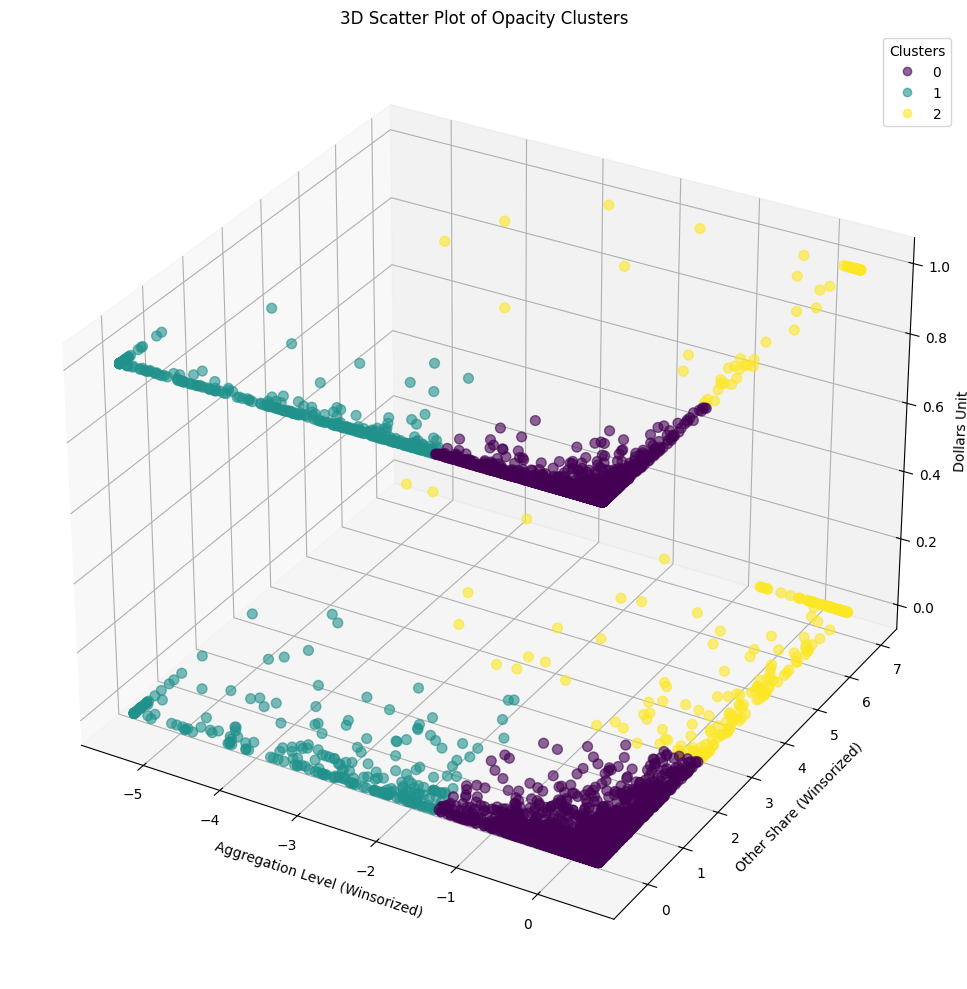

In [81]:
# Plotting 3 dimension and 2 k clusters
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Fit model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
df_opacity["opacity_cluster"] = kmeans.fit_predict(X)

# Evaluate clusters
print(df_opacity.groupby("opacity_cluster")[features_scale + binary].mean())

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_x['aggregation_level_w'],
    df_x['other_share_w'],
    df_x['dollars_unit'],
    c=df_opacity['opacity_cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6
)
ax.set_xlabel('Aggregation Level (Winsorized)')
ax.set_ylabel('Other Share (Winsorized)')
ax.set_zlabel('Dollars Unit')
plt.title('3D Scatter Plot of Opacity Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.tight_layout()
plt.show()


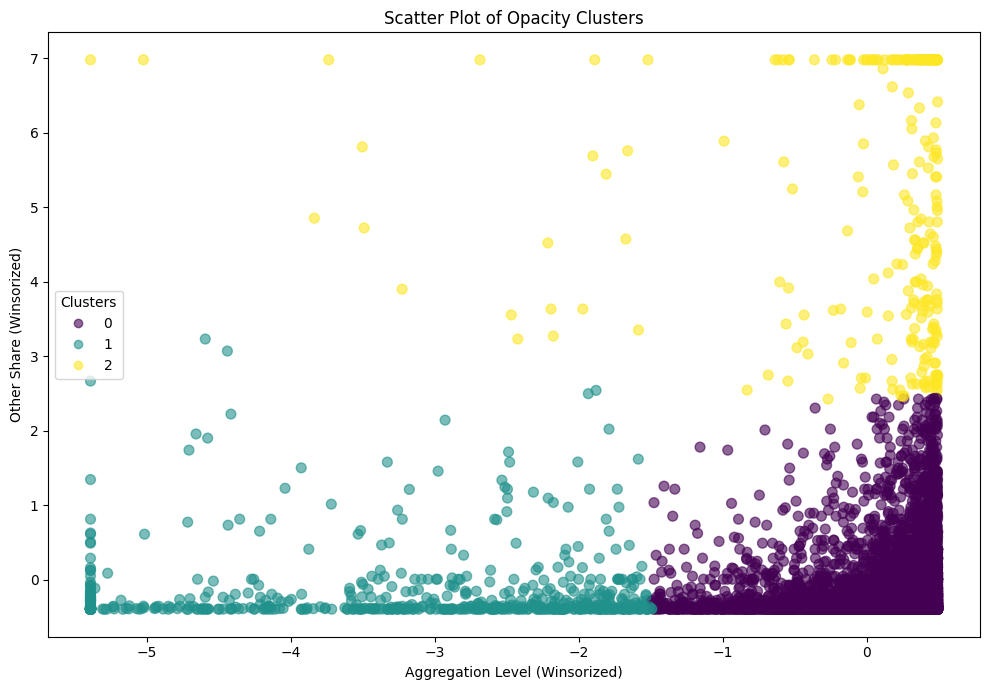

In [75]:
# generate a scatter plot of aggregation_level_w vs other_share_w colored by opacity_cluster:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_x['aggregation_level_w'],
    df_x['other_share_w'],
    c=df_opacity['opacity_cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6
)
plt.xlabel('Aggregation Level (Winsorized)')
plt.ylabel('Other Share (Winsorized)')
plt.title('Scatter Plot of Opacity Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.tight_layout()
plt.show()


In [ ]:
# Dir_test = '/Users/anhnguyen/Library/CloudStorage/Box-Box/My Box Notes/Fall 2025/AAE 722 Machine Learning in Applied Economic Analysis/Final Project'
# df_opacity.to_csv(Dir_test + "/pacity_measures.csv", index=False)


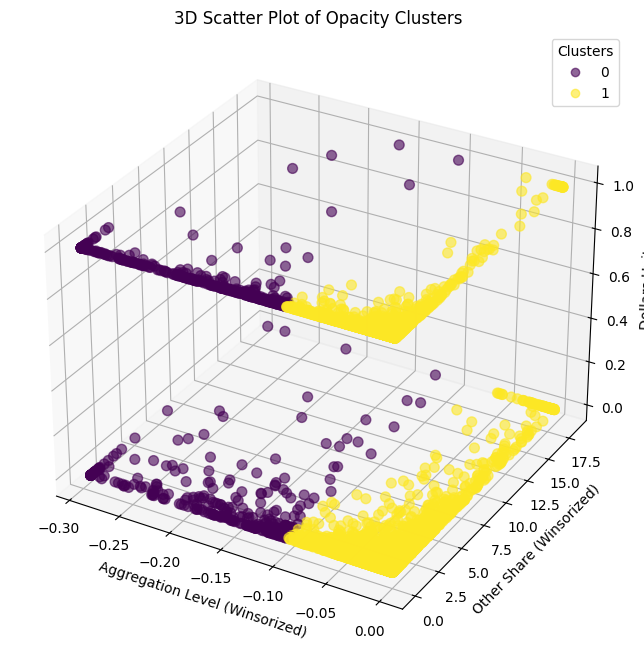

In [52]:
# Plotting 3 dimension and 2 k clusters
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_opacity['aggregation_level_w'],
    df_opacity['other_share_w'],
    df_opacity['dollars_unit'],
    c=df_opacity['opacity_cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6
)
ax.set_xlabel('Aggregation Level (Winsorized)')
ax.set_ylabel('Other Share (Winsorized)')
ax.set_zlabel('Dollars Unit')
plt.title('3D Scatter Plot of Opacity Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()



## Merge Into Main Analysis

In [27]:
# Load new dataset that will merge with cluster dataset later
final_path = base_path / "../Data/priorbalancedpanel.dta"
df_data = pd.read_stata(final_path)

# Drop if loc!="USA"
df_data = df_data[df_data["loc"] == "USA"].copy()

# Duplicates drop cik datadate,force
df_data = df_data.drop_duplicates(subset=["cik", "datadate"])


In [28]:
# check headings of df_opacity
#print(df_opacity.dtypes)

In [29]:
# normalize datadate and make comparable cik strings, then show unmatched examples

# normalize datadate (dates only)
df_opacity["datadate"] = pd.to_datetime(df_opacity["datadate"], errors="coerce").dt.normalize()
df_data["datadate"] = pd.to_datetime(df_data["datadate"], errors="coerce").dt.normalize()

# lowercase heading CIK of df_opacity
df_opacity = df_opacity.rename(columns={"CIK": "cik"})
# create comparable cik string keys for both (preserve NaNs safely)
df_opacity["CIK"] = pd.to_numeric(df_opacity["cik"], errors="coerce").astype("Int64").astype(str)
# for df_data, convert numeric-like to Int then to str to remove '.0' if present
df_data["cik"] = pd.to_numeric(df_data["cik"], errors="coerce").astype("Int64").astype(str)

# sizes / uniques
print("unique df_k keys:", df_opacity[["cik","datadate"]].drop_duplicates().shape[0])
print("unique df_data keys:", df_data[["cik","datadate"]].drop_duplicates().shape[0])


unique df_k keys: 9297
unique df_data keys: 9840


In [30]:
x

NameError: name 'x' is not defined

In [ ]:
# merge df_opacity into df_data and drop rows with no match
df_final = pd.merge(
    df_data,
    df_opacity,
    on=["cik", "datadate"],
    how="inner"  # inner join to drop non-matching rows
)


## Export to dta

In [ ]:
# Export to dta data (use Stata 13+ format to allow long strings)
output_final_path = base_path / "../Data/priorbalancedpanel_with_opacity.dta"
df_final.to_stata(output_final_path, write_index=False, version=117)
print("Final dataset with opacity clusters exported to:", output_final_path)